In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")

d:\Placement Projects\NLP text summarizer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train = dataset["train"]

In [4]:
test = dataset["test"]
validation = dataset["validation"]

In [6]:
print(len(train))
print(len(test))
print(len(validation))

287113
11490
13368


In [7]:
df = pd.DataFrame(train)
df.head()

,article,highlights,id
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287113 entries, 0 to 287112
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   article     287113 non-null  object
 1   highlights  287113 non-null  object
 2   id          287113 non-null  object
dtypes: object(3)
memory usage: 6.6+ MB


In [9]:
df.isnull().sum()

article       0
highlights    0
id            0
dtype: int64

### Article Length Analysis

In [17]:
df["article_length"] = df["article"].apply(len)

In [19]:
df["summary_length"] = df["highlights"].apply(len)

In [22]:
df[["article_length", "summary_length"]].describe()

,article_length,summary_length
count,287113.000000,287113.000000
mean,4033.661722,294.770390
std,1954.339537,120.197405
min,48.000000,14.000000
25%,2583.000000,218.000000
50%,3682.000000,280.000000
75%,5117.000000,342.000000
max,15925.000000,7388.000000


In [21]:
df.head()

,article,highlights,id,article_length,summary_length
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4,2527,217
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9,4051,281
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37,3940,224
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88,2620,185
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a,5764,273


### Article Length Distribution

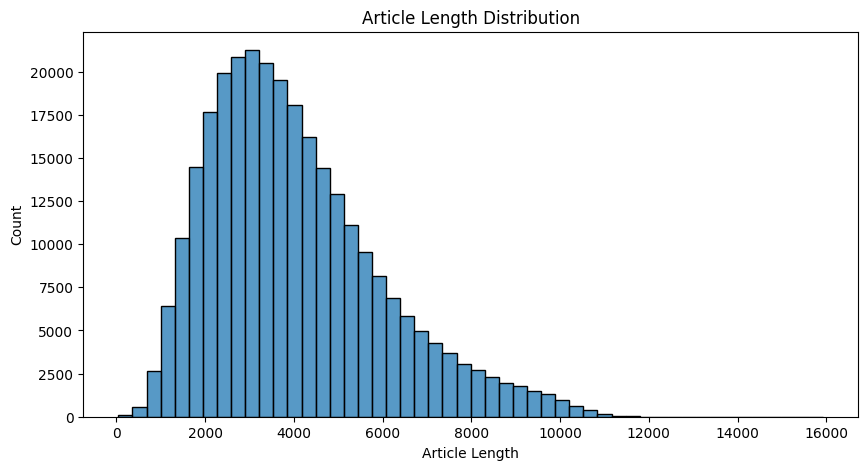

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(df["article_length"], bins=50)

plt.title("Article Length Distribution")
plt.xlabel("Article Length")
plt.ylabel("Count")

plt.show()

### Summary Length Distribution

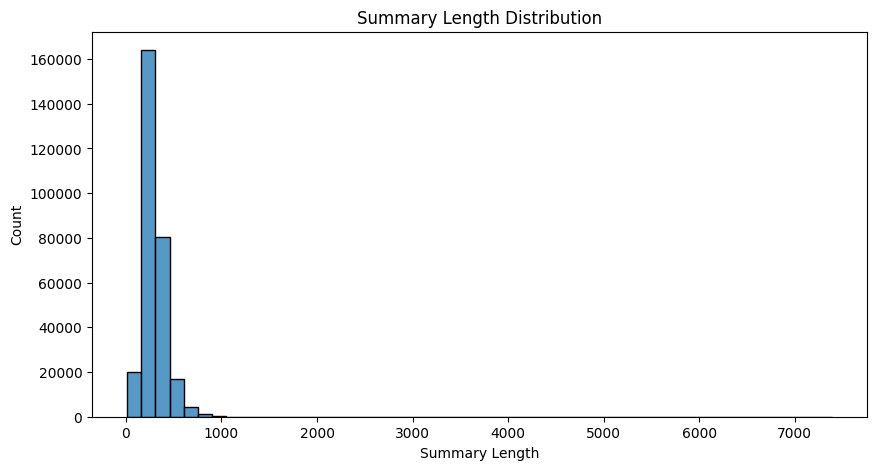

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df["summary_length"], bins=50)

plt.title("Summary Length Distribution")
plt.xlabel("Summary Length")
plt.ylabel("Count")

plt.show()

### Word Count Analysis

In [25]:
def word_count(text):
    return len(text.split())

In [26]:
df["article_word_count"] = df["article"].apply(word_count)
df["summary_word_count"] = df["highlights"].apply(word_count)

In [27]:
df[["article_word_count","summary_word_count"]].describe()

,article_word_count,summary_word_count
count,287113.000000,287113.000000
mean,691.870326,51.574101
std,336.500292,21.256336
min,8.000000,4.000000
25%,443.000000,38.000000
50%,632.000000,48.000000
75%,877.000000,60.000000
max,2347.000000,1296.000000


### Word Count Distribution

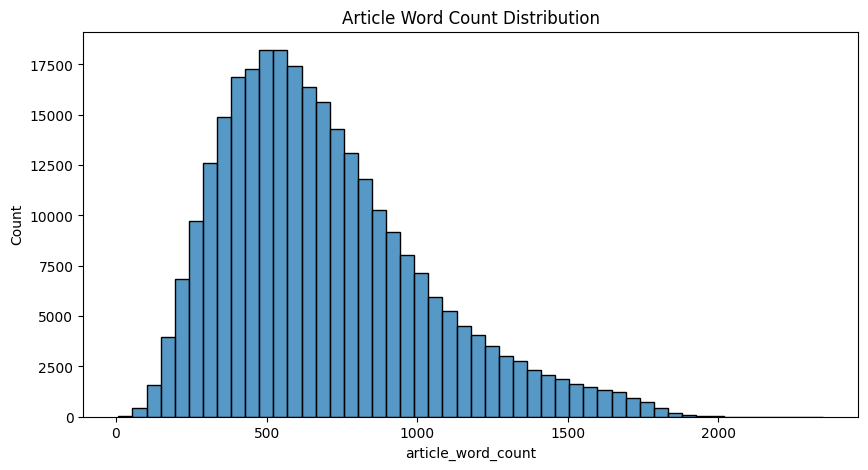

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(df["article_word_count"], bins=50)

plt.title("Article Word Count Distribution")

plt.show()

### Summary vs Article Relationship

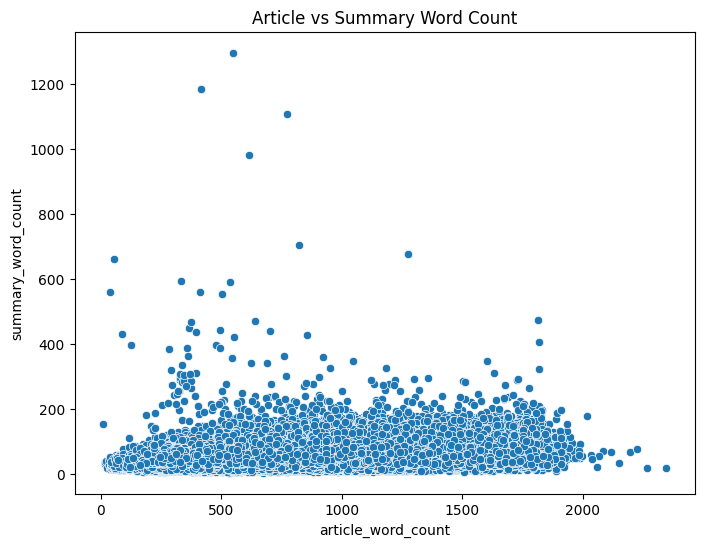

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["article_word_count"],
    y=df["summary_word_count"]
)

plt.title("Article vs Summary Word Count")

plt.show()

### Example Article and Summary

In [30]:
print("ARTICLE:\n")
print(df["article"][0])

print("\n\nSUMMARY:\n")
print(df["highlights"][0])

ARTICLE:

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Deta

## Key Observations
- Articles are much longer than summaries.
- Average article length ≈ 700–800 words.
- Average summary length ≈ 50–60 words.
- Dataset contains professionally written summaries.